<a href="https://colab.research.google.com/github/ngocnhihophuong2599-max/TH_Deep/blob/main/tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


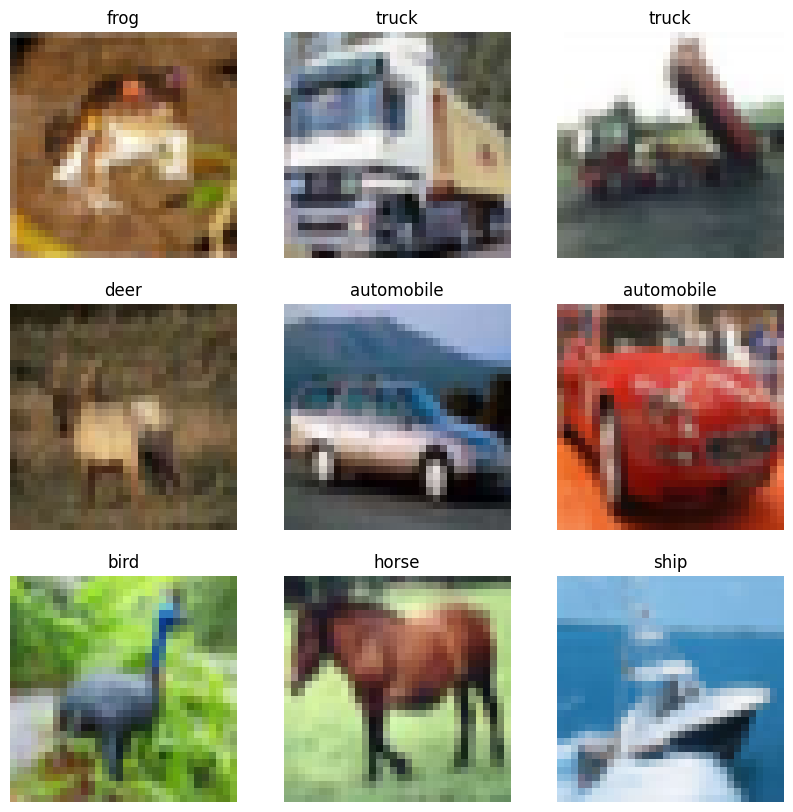

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.3187 - loss: 1.8769 - val_accuracy: 0.3771 - val_loss: 1.7388
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.4004 - loss: 1.6769 - val_accuracy: 0.4143 - val_loss: 1.6199
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4327 - loss: 1.5839 - val_accuracy: 0.4528 - val_loss: 1.5336
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.4520 - loss: 1.5351 - val_accuracy: 0.4556 - val_loss: 1.5399
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.4661 - loss: 1.4891 - val_accuracy: 0.4762 - val_loss: 1.4797
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.4782 - loss: 1.4535 - val_accuracy: 0.4656 - val_loss: 1.4950
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.4903 - loss: 1.4236 - val_accuracy: 0.4497 - val_loss: 1.5353
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.5016 - loss: 1.3945 - 

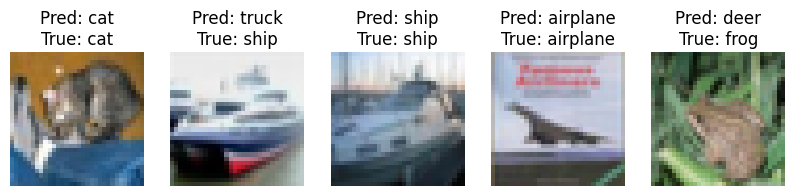

In [2]:

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# LOAD DATASET CIFAR10
# ==============================

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

x_train = x_train / 255.0
x_test = x_test / 255.0


plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

model = models.Sequential()

# Chuyển ảnh 32x32x3 thành vector
model.add(layers.Flatten(input_shape=(32, 32, 3)))

# Hidden Layer 1
model.add(layers.Dense(512, activation='relu'))

# Hidden Layer 2
model.add(layers.Dense(256, activation='relu'))

# Hidden Layer 3
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)


test_loss, test_acc = model.evaluate(x_test, y_test)

print("\nĐộ chính xác trên tập test:", test_acc)

predictions = model.predict(x_test)

plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(x_test[i])

    predicted_label = np.argmax(predictions[i])

    true_label = y_test[i][0]

    plt.title(
        f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}"
    )

    plt.axis('off')

plt.show()